# Lab 00: Football Fourth Down Decisions

---
author: Trishla Nair
date: August 30, 2024
embed-resources: true
---

## Introduction

## Methods

In [2]:
# imports
import pandas as pd
import pyarrow
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data

In [3]:
# load data
football_train = pd.read_parquet("https://cs307.org/lab-00/data/football-train.parquet")
football_test = pd.read_parquet("https://cs307.org/lab-00/data/football-test.parquet")

In [4]:
football_train

,togo,yardline,converted,play_type
0,5.0,20.0,Yes,Pass
1,2.0,23.0,Yes,Pass
2,1.0,70.0,Yes,Run
3,3.0,3.0,Yes,Pass
4,1.0,36.0,No,Run
...,...,...,...,...
1985,11.0,24.0,No,Pass
1986,10.0,48.0,No,Pass
1987,2.0,40.0,Yes,Pass
1988,1.0,21.0,No,Pass


In [5]:
football_test

,togo,yardline,converted,play_type
0,2.0,40.0,Yes,Pass
1,2.0,64.0,Yes,Pass
2,1.0,1.0,Yes,Pass
3,1.0,10.0,Yes,Run
4,1.0,66.0,Yes,Pass
...,...,...,...,...
790,1.0,1.0,No,Run
791,1.0,66.0,No,Run
792,3.0,11.0,Yes,Pass
793,2.0,26.0,Yes,Run


)

In [6]:
# summary statistics
table = pd.crosstab(index = football_train["play_type"],columns = football_train["converted"])
table

converted,No,Yes
play_type,,
Pass,703,552
Run,257,478


In [7]:
print("togo mean: ", football_train["togo"].mean(),
      "\n","yardline mean:",football_train["yardline"].mean(),
      "\n","togo std: ", football_train["togo"].std(),
     "\n","yardline std:",football_train["yardline"].std())

togo mean:  4.234673366834171 
 yardline mean: 37.48643216080402 
 togo std:  4.6673888440177755 
 yardline std: 22.115232900162464


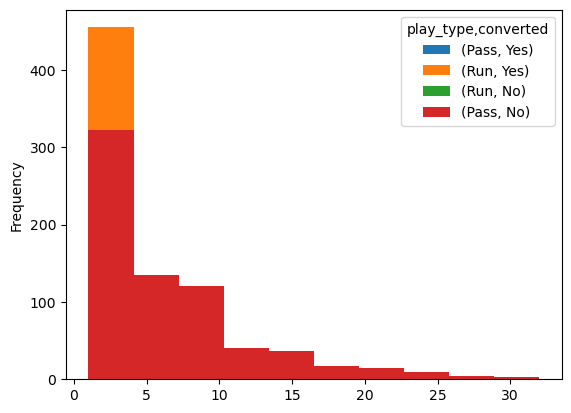

In [40]:
# visualizations
plt1 = football_train.pivot(columns=['play_type','converted'], values= "togo").plot.hist()
plt.show()

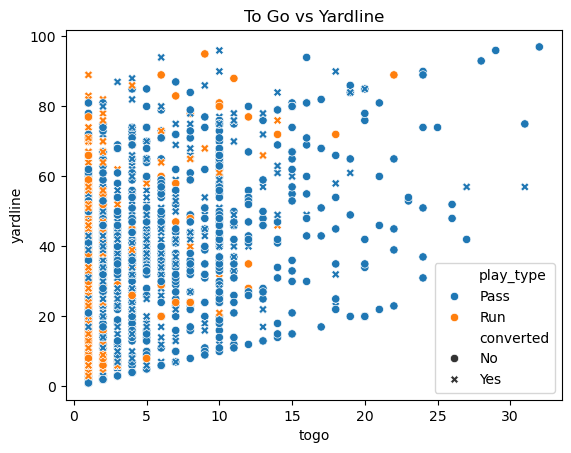

In [53]:
plt1 = sns.scatterplot(x = football_train['togo'], y = football_train['yardline'],hue = football_train["play_type"], style = football_train["converted"])
plt.title("To Go vs Yardline")
plt.show()

### Models

In [9]:
# process data for ML
X_train = football_train.drop(columns=["converted"])
X_train = pd.get_dummies(X_train, dtype=float, drop_first=True)
y_train = football_train["converted"]

In [10]:
# import random forest model
from sklearn.ensemble import RandomForestClassifier

# initialize model
mod = RandomForestClassifier(n_estimators=25, random_state=42)

# fit model
_ = mod.fit(X_train, y_train)

In [11]:
# train models
# create X and y for test
X_test = football_test.drop(columns=["converted"])
X_test = pd.get_dummies(X_test, dtype=float, drop_first=True)
y_test = football_test["converted"]

## Results

In [12]:
# report model metrics
from joblib import dump
dump(mod, "fourth-down.joblib")

['fourth-down.joblib']

## Discussion

Most of the data iscloser together when the to go valuse are smaller and the yardlines are as well.

### Conclusion

Based off this model, I don't believe it is a good fit to the situation at hand. The data is organized in such a way that the model cannot accurately predict future points that lie with in the constraints.